# Hybrid Models

Tres arquitecturas híbridas comparadas contra los baselines del Experiments.ipynb.
Todas evalúan sobre el mismo test set fijo (`data/splits/test/`).

- **Opción A** — YOLO26s como extractor de features + Transformer clasificador
- **Opción B** — Ensemble YOLO26s + EfficientNetV2-S (promedio de probabilidades)
- **Opción C** — EfficientNetV2-S congelado + cabeza de atención entrenable

**Prerequisito:** haber corrido `Experiments.ipynb` con al menos
`yolo26s-cls` y `efficientnet_v2_s` en los 3 splits.


## 0. Configuración


In [1]:
import json
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torchvision.datasets import ImageFolder
from torchvision import transforms
import torchvision.models as tv_models
from torchmetrics import Accuracy, F1Score, Precision, Recall, ConfusionMatrix
import lightning as L
from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping
from lightning.pytorch.loggers import CSVLogger
from ultralytics import YOLO

torch.set_float32_matmul_precision("high")
L.seed_everything(42, workers=True)

ROOT        = Path("..").resolve()
SPLITS_DIR  = ROOT / "data" / "splits"
MODELS_DIR  = ROOT / "models"
RESULTS_DIR = ROOT / "results"
HYBRID_DIR  = ROOT / "models" / "hybrid"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
HYBRID_DIR.mkdir(parents=True, exist_ok=True)

SPLITS      = ["full", "subset_25", "subset_10", "subset_05"]
CLASSES     = ["Necrotic-Tumor", "Non-Tumor", "Viable-Tumor"]
NUM_CLASSES = 3
DEVICE      = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Device : {DEVICE}")
print(f"ROOT   : {ROOT}")




Seed set to 42


Device : cuda
ROOT   : /home/asdromundo/Documentos/classification


## Opción A — YOLO26s extractor + Transformer clasificador

**Idea:** YOLO26s ya aprendió representaciones de tejido histopatológico.
En lugar de usar su cabeza de clasificación lineal, extraemos el feature
vector del penúltimo layer y entrenamos un Transformer encoder ligero
sobre esos embeddings. La hipótesis es que el mecanismo de atención puede
capturar relaciones entre features locales que la cabeza lineal ignora.

**Justificación para el examen:** el extractor permanece congelado —
solo se entrena la cabeza. Esto es especialmente relevante en few-shot
porque minimiza los parámetros a aprender con pocos datos.


### A.1 — Inspección de capas del modelo YOLO26s


In [2]:
def inspect_yolo_layers(model_path: str):
    """Imprime las capas del modelo para identificar el penúltimo layer."""
    model = YOLO(model_path)
    print("Arquitectura del modelo YOLO:")
    for i, layer in enumerate(model.model.model):
        print(f"  [{i:2d}] {type(layer).__name__}")
    return model

# Cargar el modelo entrenado en full split
yolo_ckpt_full = str(MODELS_DIR / "yolo" / "yolo26s-cls" / "full" / "train" / "weights" / "best.pt")
yolo_model_inspector = inspect_yolo_layers(yolo_ckpt_full)




Arquitectura del modelo YOLO:
  [ 0] Conv
  [ 1] Conv
  [ 2] C3k2
  [ 3] Conv
  [ 4] C3k2
  [ 5] Conv
  [ 6] C3k2
  [ 7] Conv
  [ 8] C3k2
  [ 9] C2PSA
  [10] Classify


### A.2 — Extracción de embeddings

Usamos el argumento `embed` de Ultralytics para extraer el feature vector
antes de la capa de clasificación final. El índice del layer a extraer
se determina inspeccionando la salida de la celda anterior —
típicamente es el penúltimo layer (len(model.model.model) - 2).


In [3]:
def get_embed_layer_idx(model_path: str) -> int:
    """Retorna el índice del penúltimo layer (antes del clasificador)."""
    model = YOLO(model_path)
    n = len(model.model.model)
    # El último layer es el clasificador lineal, el penúltimo es el pooling/flatten
    return n - 2


def extract_embeddings(
    yolo_ckpt: str,
    data_dir: Path,
    embed_layer: int,
    batch_size: int = 64,
    imgsz: int = 224,
) -> tuple[torch.Tensor, torch.Tensor]:
    model = YOLO(yolo_ckpt)

    dataset  = ImageFolder(root=str(data_dir))
    img_paths = [s[0] for s in dataset.samples]
    labels    = [s[1] for s in dataset.samples]

    all_embeds = []

    for i in range(0, len(img_paths), batch_size):
        batch_paths = img_paths[i:i + batch_size]
        results = model(batch_paths, embed=[embed_layer], imgsz=imgsz, verbose=False)
        # results es una lista de tensores (embed_dim,) — uno por imagen
        batch_embeds = torch.stack([
            r if isinstance(r, torch.Tensor) else torch.tensor(r)
            for r in results
        ])
        all_embeds.append(batch_embeds)

        if (i // batch_size) % 5 == 0:
            print(f"  [{i}/{len(img_paths)}] embeddings extraídos...")

    embeddings = torch.cat(all_embeds, dim=0)
    labels_t   = torch.tensor(labels, dtype=torch.long)

    print(f"  -> Shape embeddings: {embeddings.shape}")  # debería ser (N, 512)
    print(f"  -> Shape labels:     {labels_t.shape}")

    return embeddings, labels_t





In [4]:
# Extraer y guardar embeddings para cada split (se hace una sola vez)
embed_cache = {}

for split in SPLITS:
    cache_path = HYBRID_DIR / f"yolo26s_embeddings_{split}.pt"

    if cache_path.exists():
        print(f"[{split}] Cargando embeddings desde caché...")
        embed_cache[split] = torch.load(cache_path, weights_only=True)
        continue

    print(f"\n[{split}] Extrayendo embeddings...")
    yolo_ckpt  = str(MODELS_DIR / "yolo" / "yolo26s-cls" / split / "train" / "weights" / "best.pt")
    embed_layer = get_embed_layer_idx(yolo_ckpt)
    print(f"  Usando layer de embedding: {embed_layer}")

    splits = {}
    for subset in ["train", "val"]:
        data_dir = SPLITS_DIR / split / subset
        emb, lbl = extract_embeddings(yolo_ckpt, data_dir, embed_layer)
        splits[subset] = {"embeddings": emb, "labels": lbl}

    # Test siempre desde el mismo modelo (full) para consistencia
    yolo_ckpt_test = str(MODELS_DIR / "yolo" / "yolo26s-cls" / "full" / "train" / "weights" / "best.pt")
    embed_layer_test = get_embed_layer_idx(yolo_ckpt_test)
    emb_test, lbl_test = extract_embeddings(yolo_ckpt_test, SPLITS_DIR / "test", embed_layer_test)
    splits["test"] = {"embeddings": emb_test, "labels": lbl_test}

    torch.save(splits, cache_path)
    embed_cache[split] = splits
    print(f"  Embeddings guardados en {cache_path}")

print("\nDimensión de embeddings:")
for split in SPLITS:
    e = embed_cache[split]["train"]["embeddings"]
    print(f"  {split}: {e.shape}")




[full] Cargando embeddings desde caché...
[subset_25] Cargando embeddings desde caché...
[subset_10] Cargando embeddings desde caché...
[subset_05] Cargando embeddings desde caché...

Dimensión de embeddings:
  full: torch.Size([730, 512])
  subset_25: torch.Size([181, 512])
  subset_10: torch.Size([70, 512])
  subset_05: torch.Size([34, 512])


### A.3 — Transformer clasificador sobre embeddings YOLO


In [5]:
class TransformerHead(nn.Module):
    """
    Cabeza de clasificación basada en Transformer encoder.
    Recibe un vector de features 1D (embed_dim,) y produce logits.

    Arquitectura:
        Linear projection -> positional token [CLS] -> N - TransformerEncoderLayer -> clasificador
    """
    def __init__(
        self,
        embed_dim: int,
        num_classes: int,
        proj_dim: int = 256,
        n_heads: int = 4,
        n_layers: int = 2,
        dropout: float = 0.1,
    ):
        super().__init__()

        # Proyección al espacio del transformer
        self.projection = nn.Sequential(
            nn.Linear(embed_dim, proj_dim),
            nn.LayerNorm(proj_dim),
            nn.GELU(),
        )

        # Token [CLS] aprendible
        self.cls_token = nn.Parameter(torch.randn(1, 1, proj_dim))

        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model    = proj_dim,
            nhead      = n_heads,
            dim_feedforward = proj_dim * 4,
            dropout    = dropout,
            activation = "gelu",
            batch_first = True,
            norm_first  = True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)

        # Clasificador final sobre el token CLS
        self.classifier = nn.Sequential(
            nn.LayerNorm(proj_dim),
            nn.Dropout(dropout),
            nn.Linear(proj_dim, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (batch, embed_dim)
        x = self.projection(x)              # (batch, proj_dim)
        x = x.unsqueeze(1)                  # (batch, 1, proj_dim) — secuencia de 1 token

        # Concatenar token CLS
        cls = self.cls_token.expand(x.size(0), -1, -1)  # (batch, 1, proj_dim)
        x = torch.cat([cls, x], dim=1)     # (batch, 2, proj_dim)

        x = self.transformer(x)             # (batch, 2, proj_dim)
        cls_out = x[:, 0]                   # (batch, proj_dim) — solo el CLS token

        return self.classifier(cls_out)     # (batch, num_classes)


class LitTransformerHead(L.LightningModule):
    def __init__(self, embed_dim: int, num_classes: int, lr: float = 1e-3):
        super().__init__()
        self.save_hyperparameters()
        self.model    = TransformerHead(embed_dim, num_classes)
        self.criterion = nn.CrossEntropyLoss()

        task = "multiclass"
        self.train_acc = Accuracy(task=task, num_classes=num_classes)
        self.val_acc   = Accuracy(task=task, num_classes=num_classes)
        self.test_acc  = Accuracy(task=task, num_classes=num_classes)
        self.test_f1   = F1Score(task=task, num_classes=num_classes, average="macro")
        self.test_prec = Precision(task=task, num_classes=num_classes, average="macro")
        self.test_rec  = Recall(task=task, num_classes=num_classes, average="macro")
        self.test_cm   = ConfusionMatrix(task=task, num_classes=num_classes)

    def forward(self, x):
        return self.model(x)

    def _step(self, batch):
        x, y  = batch
        logits = self(x)
        loss   = self.criterion(logits, y)
        preds  = logits.argmax(dim=1)
        return loss, preds, y

    def training_step(self, batch, _):
        loss, preds, y = self._step(batch)
        self.train_acc(preds, y)
        self.log("train_loss", loss, prog_bar=True, on_epoch=True, on_step=False)
        self.log("train_acc",  self.train_acc, prog_bar=True, on_epoch=True, on_step=False)
        return loss

    def validation_step(self, batch, _):
        loss, preds, y = self._step(batch)
        self.val_acc(preds, y)
        self.log("val_loss", loss, prog_bar=True)
        self.log("val_acc",  self.val_acc, prog_bar=True)

    def test_step(self, batch, _):
        loss, preds, y = self._step(batch)
        self.test_acc(preds, y); self.test_f1(preds, y)
        self.test_prec(preds, y); self.test_rec(preds, y)
        self.test_cm(preds, y)
        self.log("test_loss", loss)
        self.log("test_acc",  self.test_acc)
        self.log("test_f1",   self.test_f1)
        self.log("test_precision", self.test_prec)
        self.log("test_recall",    self.test_rec)

    def on_test_epoch_end(self):
        self.confusion_matrix = self.test_cm.compute().cpu().tolist()

    def configure_optimizers(self):
        opt = torch.optim.AdamW(self.parameters(), lr=self.hparams.lr, weight_decay=1e-4)
        sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=self.trainer.max_epochs)
        return {"optimizer": opt, "lr_scheduler": sch}





In [ ]:
def run_option_a(split: str, epochs: int = 100, batch_size: int = 128,
                 lr: float = 1e-3, patience: int = 20):
    """Entrena y evalúa la Opción A para un split dado."""

    result_path = RESULTS_DIR / f"hybrid_A_{split}.json"Lightning
    if result_path.exists():
        print(f"  ↩  Saltando hybrid_A - {split} (ya existe)")
        with open(result_path) as f:
            return json.load(f)

    print(f"\n{'='*60}")
    print(f"  Híbrido A: YOLO26s extractor + Transformer")
    print(f"  Split: {split}")
    print(f"{'='*60}")

    # Cargar embeddings precalculados
    data = embed_cache[split]
    embed_dim = data["train"]["embeddings"].shape[1]
    print(f"  Embed dim: {embed_dim}")

    def make_loader(subset: str, shuffle: bool) -> DataLoader:
        ds = TensorDataset(data[subset]["embeddings"], data[subset]["labels"])
        return DataLoader(
            ds,
            batch_size=batch_size,
            shuffle=shuffle,
            num_workers=0,      # ← 0 porque los datos ya están en RAM, no en disco
            pin_memory=False,   # ← False también, pin_memory no aplica con num_workers=0
        )

    train_loader = make_loader("train", shuffle=True)
    val_loader   = make_loader("val",   shuffle=False)
    test_loader  = make_loader("test",  shuffle=False)

    # Modelo
    lit_model = LitTransformerHead(embed_dim=embed_dim, num_classes=NUM_CLASSES, lr=lr)

    ckpt_dir = HYBRID_DIR / "option_A" / split
    ckpt_dir.mkdir(parents=True, exist_ok=True)

    checkpoint_cb = ModelCheckpoint(
        dirpath=str(ckpt_dir), filename="best",
        monitor="val_acc", mode="max", save_top_k=1,
    )
    early_stop_cb = EarlyStopping(
        monitor="val_acc", patience=patience, mode="max", verbose=True,
    )
    csv_logger = CSVLogger(save_dir=str(ckpt_dir), name="", version="")

    trainer = L.Trainer(
        max_epochs=epochs, accelerator="auto", devices="auto",
        precision="16-mixed", callbacks=[checkpoint_cb, early_stop_cb],
        logger=csv_logger, enable_progress_bar=True, log_every_n_steps=5,
    )

    trainer.fit(lit_model, train_dataloaders=train_loader, val_dataloaders=val_loader)

    test_results = trainer.test(
        ckpt_path=checkpoint_cb.best_model_path,
        dataloaders=test_loader, verbose=True,
    )

    result = {
        "model": "hybrid_A_yolo26s+transformer",
        "split": split,
        "description": "YOLO26s feature extractor (frozen) + Transformer encoder head",
        "epochs_run":    trainer.current_epoch,
        "best_val_acc":  float(checkpoint_cb.best_model_score),
        "test_acc":       test_results[0].get("test_acc"),
        "test_f1":        test_results[0].get("test_f1"),
        "test_precision": test_results[0].get("test_precision"),
        "test_recall":    test_results[0].get("test_recall"),
        "test_loss":      test_results[0].get("test_loss"),
        "confusion_matrix": lit_model.confusion_matrix,
        "classes":        CLASSES,
    }

    with open(result_path, "w") as f:
        json.dump(result, f, indent=2)

    print(f"\n✓ hybrid_A - {split}")
    print(f"  test_acc : {result['test_acc']:.4f}")
    print(f"  test_f1  : {result['test_f1']:.4f}")
    return result





In [7]:
results_A = {}
for split in SPLITS:
    r = run_option_a(split)
    results_A[split] = r




  ↩  Saltando hybrid_A - full (ya existe)
  ↩  Saltando hybrid_A - subset_25 (ya existe)
  ↩  Saltando hybrid_A - subset_10 (ya existe)
  ↩  Saltando hybrid_A - subset_05 (ya existe)


## Opción B — Ensemble YOLO26s + EfficientNetV2-S

**Idea:** combinar las probabilidades softmax de ambos modelos ya entrenados
(sin re-entrenar nada). Se promedian las distribuciones de probabilidad —
si los modelos cometen errores en imágenes diferentes, el ensemble los cancela.

**Justificación:** YOLO26s y EfficientNetV2-S tienen backbones distintos,
lo que maximiza la diversidad del ensemble. La correlación baja entre sus
errores es lo que hace útil combinarlos.


In [8]:
def load_lightning_model(model_key: str, split: str) -> nn.Module:
    """Carga un modelo Lightning desde su checkpoint y lo pone en eval mode."""
    from train import LitClassifier, get_pretrained_transforms  # noqa
    ckpt_path = MODELS_DIR / model_key / split / "best.ckpt"
    model = LitClassifier.load_from_checkpoint(str(ckpt_path))
    model.eval()
    model.to(DEVICE)
    return model


def get_softmax_probs(
    model: nn.Module,
    data_dir: Path,
    transform,
    batch_size: int = 128,
) -> tuple[torch.Tensor, torch.Tensor]:
    """Retorna probabilidades softmax e labels para un directorio ImageFolder."""
    dataset = ImageFolder(root=str(data_dir), transform=transform)
    loader  = DataLoader(dataset, batch_size=batch_size, shuffle=False,
                         num_workers=4, pin_memory=True)
    all_probs, all_labels = [], []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(DEVICE)
            logits = model(imgs) if not hasattr(model, "model") else model.model(imgs)
            probs  = torch.softmax(logits, dim=1).cpu()
            all_probs.append(probs)
            all_labels.append(labels)

    return torch.cat(all_probs), torch.cat(all_labels)


def get_yolo_probs(
    yolo_ckpt: str,
    data_dir: Path,
    batch_size: int = 128,
    imgsz: int = 224,
) -> tuple[torch.Tensor, torch.Tensor]:
    """Retorna probabilidades softmax de YOLO26s e labels."""
    model   = YOLO(yolo_ckpt)
    dataset = ImageFolder(root=str(data_dir))
    img_paths = [s[0] for s in dataset.samples]
    labels    = [s[1] for s in dataset.samples]

    all_probs = []
    for i in range(0, len(img_paths), batch_size):
        batch = img_paths[i:i+batch_size]
        results = model(batch, imgsz=imgsz, verbose=False)
        probs = torch.stack([
            torch.tensor(r.probs.data.cpu().numpy() if hasattr(r.probs, "data") else r.probs)
            for r in results
        ])
        all_probs.append(probs)

    return torch.cat(all_probs), torch.tensor(labels, dtype=torch.long)


def evaluate_ensemble(
    probs_a: torch.Tensor,
    probs_b: torch.Tensor,
    labels: torch.Tensor,
    weight_a: float = 0.5,
) -> dict:
    """Evalúa el ensemble promediando probabilidades."""
    combined = weight_a * probs_a + (1 - weight_a) * probs_b
    preds    = combined.argmax(dim=1)

    acc  = (preds == labels).float().mean().item()
    cm   = torch.zeros(NUM_CLASSES, NUM_CLASSES, dtype=torch.long)
    for t, p in zip(labels, preds):
        cm[t, p] += 1

    precisions, recalls, f1s = [], [], []
    for i in range(NUM_CLASSES):
        tp = cm[i, i].item()
        fp = cm[:, i].sum().item() - tp
        fn = cm[i, :].sum().item() - tp
        p  = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        r  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2*p*r/(p+r) if (p+r) > 0 else 0.0
        precisions.append(p); recalls.append(r); f1s.append(f1)

    return {
        "test_acc":       acc,
        "test_f1":        float(np.mean(f1s)),
        "test_precision": float(np.mean(precisions)),
        "test_recall":    float(np.mean(recalls)),
        "confusion_matrix": cm.tolist(),
    }





In [9]:
import sys
sys.path.insert(0, str(ROOT / "scripts"))
from train import get_pretrained_transforms  # noqa

results_B = {}

for split in SPLITS:
    result_path = RESULTS_DIR / f"hybrid_B_{split}.json"

    if result_path.exists():
        print(f"  ↩  Saltando hybrid_B - {split}")
        with open(result_path) as f:
            results_B[split] = json.load(f)
        continue

    print(f"\n[hybrid_B] split={split}")

    # Probabilidades YOLO26s
    yolo_ckpt  = str(MODELS_DIR / "yolo" / "yolo26s-cls" / split / "train" / "weights" / "best.pt")
    probs_yolo, labels = get_yolo_probs(yolo_ckpt, SPLITS_DIR / "test")

    # Probabilidades EfficientNetV2-S
    effnet_model = load_lightning_model("efficientnet_v2_s", split)
    transform    = get_pretrained_transforms("efficientnet_v2_s")
    probs_eff, _ = get_softmax_probs(effnet_model, SPLITS_DIR / "test", transform)

    # Ensemble con diferentes pesos — encontrar el óptimo en val
    best_weight, best_val_acc = 0.5, 0.0
    probs_yolo_val, labels_val = get_yolo_probs(yolo_ckpt, SPLITS_DIR / split / "val")
    probs_eff_val, _           = get_softmax_probs(effnet_model, SPLITS_DIR / split / "val", transform)

    for w in [0.3, 0.4, 0.5, 0.6, 0.7]:
        m = evaluate_ensemble(probs_yolo_val, probs_eff_val, labels_val, weight_a=w)
        if m["test_acc"] > best_val_acc:
            best_val_acc = m["test_acc"]
            best_weight  = w

    print(f"  Mejor peso YOLO en val: {best_weight} (val_acc={best_val_acc:.4f})")
    metrics = evaluate_ensemble(probs_yolo, probs_eff, labels, weight_a=best_weight)

    result = {
        "model":       "hybrid_B_yolo26s+efficientnet_v2_s_ensemble",
        "split":       split,
        "description": f"Ensemble YOLO26s ({best_weight:.1f}) + EfficientNetV2-S ({1-best_weight:.1f})",
        "best_val_acc": best_val_acc,
        "ensemble_weight_yolo": best_weight,
        **metrics,
        "classes": CLASSES,
    }

    with open(result_path, "w") as f:
        json.dump(result, f, indent=2)

    results_B[split] = result
    print(f"  test_acc={result['test_acc']:.4f}  test_f1={result['test_f1']:.4f}")




  ↩  Saltando hybrid_B - full
  ↩  Saltando hybrid_B - subset_25
  ↩  Saltando hybrid_B - subset_10
  ↩  Saltando hybrid_B - subset_05


## Opción C — EfficientNetV2-S congelado + cabeza de atención

**Idea:** EfficientNetV2-S fue el modelo más resistente a la reducción de datos.
En lugar de re-entrenarlo completo, congelamos el backbone y agregamos un
mecanismo de atención multi-cabeza entre el feature extractor y el clasificador.
La atención aprende a ponderar diferentes regiones del feature map.

**Diferencia con Opción A:** aquí el backbone es EfficientNetV2-S (CNN)
y la atención opera sobre su feature map 2D (spatial attention),
no sobre un vector 1D como en la Opción A.


In [10]:
class EfficientNetWithAttention(nn.Module):
    """
    EfficientNetV2-S con backbone congelado y cabeza de atención multi-cabeza.

    Arquitectura:
        EfficientNetV2-S backbone (frozen) -> feature map (B, C, H, W)
        -> reshape a secuencia (B, H*W, C)
        -> Multi-Head Self-Attention
        -> Global Average Pool
        -> clasificador lineal
    """
    def __init__(self, num_classes: int, n_heads: int = 8, n_layers: int = 2,
                 dropout: float = 0.1):
        super().__init__()

        # Backbone congelado
        base = tv_models.efficientnet_v2_s(
            weights=tv_models.EfficientNet_V2_S_Weights.DEFAULT
        )
        # Extraer solo el feature extractor (sin avgpool ni classifier)
        self.backbone  = base.features  # -> (B, 1280, 7, 7) para input 224-224
        self.feat_dim  = 1280

        for p in self.backbone.parameters():
            p.requires_grad = False

        # Cabeza de atención
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=self.feat_dim, nhead=n_heads,
            dim_feedforward=self.feat_dim * 2, dropout=dropout,
            activation="gelu", batch_first=True, norm_first=True,
        )
        self.attention = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.norm      = nn.LayerNorm(self.feat_dim)
        self.dropout   = nn.Dropout(dropout)
        self.classifier = nn.Linear(self.feat_dim, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Backbone
        with torch.no_grad():
            feats = self.backbone(x)        # (B, 1280, H, W)

        B, C, H, W = feats.shape
        seq = feats.view(B, C, H * W).permute(0, 2, 1)  # (B, H*W, C)

        # Atención sobre los tokens espaciales
        seq = self.attention(seq)           # (B, H*W, C)
        pooled = seq.mean(dim=1)            # (B, C) — global average
        pooled = self.norm(pooled)
        return self.classifier(self.dropout(pooled))


class LitEffNetAttention(L.LightningModule):
    def __init__(self, num_classes: int, lr: float = 1e-3):
        super().__init__()
        self.save_hyperparameters()
        self.model     = EfficientNetWithAttention(num_classes)
        self.criterion = nn.CrossEntropyLoss()

        task = "multiclass"
        self.train_acc = Accuracy(task=task, num_classes=num_classes)
        self.val_acc   = Accuracy(task=task, num_classes=num_classes)
        self.test_acc  = Accuracy(task=task, num_classes=num_classes)
        self.test_f1   = F1Score(task=task, num_classes=num_classes, average="macro")
        self.test_prec = Precision(task=task, num_classes=num_classes, average="macro")
        self.test_rec  = Recall(task=task, num_classes=num_classes, average="macro")
        self.test_cm   = ConfusionMatrix(task=task, num_classes=num_classes)

    def forward(self, x): return self.model(x)

    def _step(self, batch):
        x, y = batch
        logits = self(x)
        loss   = self.criterion(logits, y)
        return loss, logits.argmax(1), y

    def training_step(self, batch, _):
        loss, preds, y = self._step(batch)
        self.train_acc(preds, y)
        self.log("train_loss", loss, prog_bar=True, on_epoch=True, on_step=False)
        self.log("train_acc",  self.train_acc, prog_bar=True, on_epoch=True, on_step=False)
        return loss

    def validation_step(self, batch, _):
        loss, preds, y = self._step(batch)
        self.val_acc(preds, y)
        self.log("val_loss", loss, prog_bar=True)
        self.log("val_acc",  self.val_acc, prog_bar=True)

    def test_step(self, batch, _):
        loss, preds, y = self._step(batch)
        self.test_acc(preds, y); self.test_f1(preds, y)
        self.test_prec(preds, y); self.test_rec(preds, y)
        self.test_cm(preds, y)
        self.log("test_loss", loss)
        self.log("test_acc",  self.test_acc)
        self.log("test_f1",   self.test_f1)
        self.log("test_precision", self.test_prec)
        self.log("test_recall",    self.test_rec)

    def on_test_epoch_end(self):
        self.confusion_matrix = self.test_cm.compute().cpu().tolist()

    def configure_optimizers(self):
        # Solo optimizar los parámetros de atención (backbone congelado)
        trainable = [p for p in self.parameters() if p.requires_grad]
        opt = torch.optim.AdamW(trainable, lr=self.hparams.lr, weight_decay=1e-4)
        sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=self.trainer.max_epochs)
        return {"optimizer": opt, "lr_scheduler": sch}





In [11]:
def run_option_c(split: str, epochs: int = 100, batch_size: int = 128,
                 lr: float = 1e-3, patience: int = 20):
    """Entrena y evalúa la Opción C para un split dado."""
    result_path = RESULTS_DIR / f"hybrid_C_{split}.json"
    if result_path.exists():
        print(f"  ↩  Saltando hybrid_C - {split}")
        with open(result_path) as f:
            return json.load(f)

    print(f"\n{'='*60}")
    print(f"  Híbrido C: EfficientNetV2-S + Attention Head")
    print(f"  Split: {split}")
    print(f"{'='*60}")

    # Usar los transforms oficiales de EfficientNetV2-S
    transform = tv_models.EfficientNet_V2_S_Weights.DEFAULT.transforms()

    def make_loader(data_dir, shuffle):
        ds = ImageFolder(root=str(data_dir), transform=transform)
        return DataLoader(ds, batch_size=batch_size, shuffle=shuffle,
                          num_workers=6, pin_memory=True, persistent_workers=True)

    train_loader = make_loader(SPLITS_DIR / split / "train", shuffle=True)
    val_loader   = make_loader(SPLITS_DIR / split / "val",   shuffle=False)
    test_loader  = make_loader(SPLITS_DIR / "test",          shuffle=False)

    lit_model = LitEffNetAttention(num_classes=NUM_CLASSES, lr=lr)

    # Contar parámetros entrenables
    trainable = sum(p.numel() for p in lit_model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in lit_model.parameters())
    print(f"  Parámetros entrenables: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")

    ckpt_dir = HYBRID_DIR / "option_C" / split
    ckpt_dir.mkdir(parents=True, exist_ok=True)

    checkpoint_cb = ModelCheckpoint(
        dirpath=str(ckpt_dir), filename="best",
        monitor="val_acc", mode="max", save_top_k=1,
    )
    early_stop_cb = EarlyStopping(
        monitor="val_acc", patience=patience, mode="max", verbose=True,
    )
    csv_logger = CSVLogger(save_dir=str(ckpt_dir), name="", version="")

    trainer = L.Trainer(
        max_epochs=epochs, accelerator="auto", devices="auto",
        precision="16-mixed", callbacks=[checkpoint_cb, early_stop_cb],
        logger=csv_logger, enable_progress_bar=True, log_every_n_steps=5,
    )

    trainer.fit(lit_model, train_dataloaders=train_loader, val_dataloaders=val_loader)

    test_results = trainer.test(
        ckpt_path=checkpoint_cb.best_model_path,
        dataloaders=test_loader, verbose=True,
    )

    result = {
        "model":       "hybrid_C_efficientnet_v2_s+attention",
        "split":       split,
        "description": "EfficientNetV2-S backbone (frozen) + Multi-Head Self-Attention head",
        "epochs_run":  trainer.current_epoch,
        "best_val_acc": float(checkpoint_cb.best_model_score),
        "test_acc":       test_results[0].get("test_acc"),
        "test_f1":        test_results[0].get("test_f1"),
        "test_precision": test_results[0].get("test_precision"),
        "test_recall":    test_results[0].get("test_recall"),
        "test_loss":      test_results[0].get("test_loss"),
        "confusion_matrix": lit_model.confusion_matrix,
        "classes":        CLASSES,
    }

    with open(result_path, "w") as f:
        json.dump(result, f, indent=2)

    print(f"\n✓ hybrid_C - {split}")
    print(f"  test_acc : {result['test_acc']:.4f}")
    print(f"  test_f1  : {result['test_f1']:.4f}")
    return result





In [12]:
results_C = {}
for split in SPLITS:
    r = run_option_c(split)
    results_C[split] = r




  ↩  Saltando hybrid_C - full
  ↩  Saltando hybrid_C - subset_25
  ↩  Saltando hybrid_C - subset_10
  ↩  Saltando hybrid_C - subset_05


## Comparativa final — Híbridos vs Baselines


In [13]:
# Cargar todos los resultados (baselines + híbridos)
all_results = {}
for path in sorted(RESULTS_DIR.glob("*.json")):
    with open(path) as f:
        r = json.load(f)
    key = f"{r['model']}_{r['split']}"
    all_results[key] = r

df = pd.DataFrame([
    {
        "model":     r["model"],
        "split":     r["split"],
        "test_acc":  r.get("test_acc"),
        "test_f1":   r.get("test_f1"),
    }
    for r in all_results.values()
])

split_order = ["full", "subset_25", "subset_10", "subset_05"]
df["split"] = pd.Categorical(df["split"], categories=split_order, ordered=True)
df = df.sort_values(["model", "split"]).reset_index(drop=True)




In [14]:
# Tabla comparativa
pivot_acc = df.pivot_table(index="model", columns="split", values="test_acc") * 100
pivot_f1  = df.pivot_table(index="model", columns="split", values="test_f1")  * 100

# Separar baselines e híbridos para highlighting
hybrid_models = [m for m in pivot_acc.index if m.startswith("hybrid_")]
baseline_models = [m for m in pivot_acc.index if not m.startswith("hybrid_")]

print("Test Accuracy (%) — Baselines vs Híbridos")
print(pivot_acc.reindex(columns=split_order).round(2).to_string())
print("Test f1 (%) — Baselines vs Híbridos")
print(pivot_f1.reindex(columns=split_order).round(2).to_string())


Test Accuracy (%) — Baselines vs Híbridos
split                                         full  subset_25  subset_10  subset_05
model                                                                              
alexnet                                      88.26      52.17      56.96      44.78
densenet121                                  93.04      91.30      72.17      83.48
efficientnet_b0                              94.35      90.00      86.52      80.43
efficientnet_v2_s                            91.74      90.00      89.57      81.74
hybrid_A_yolo26s+transformer                 94.35      83.48      91.74      92.17
hybrid_B_yolo26s+efficientnet_v2_s_ensemble  93.48      90.87      90.00      82.17
hybrid_C_efficientnet_v2_s+attention         93.91      80.43      84.78      70.87
resnet50                                     93.91      90.00      85.22      65.22
vgg11_bn                                     91.74      88.26      60.00      71.74
vit_b_16                          

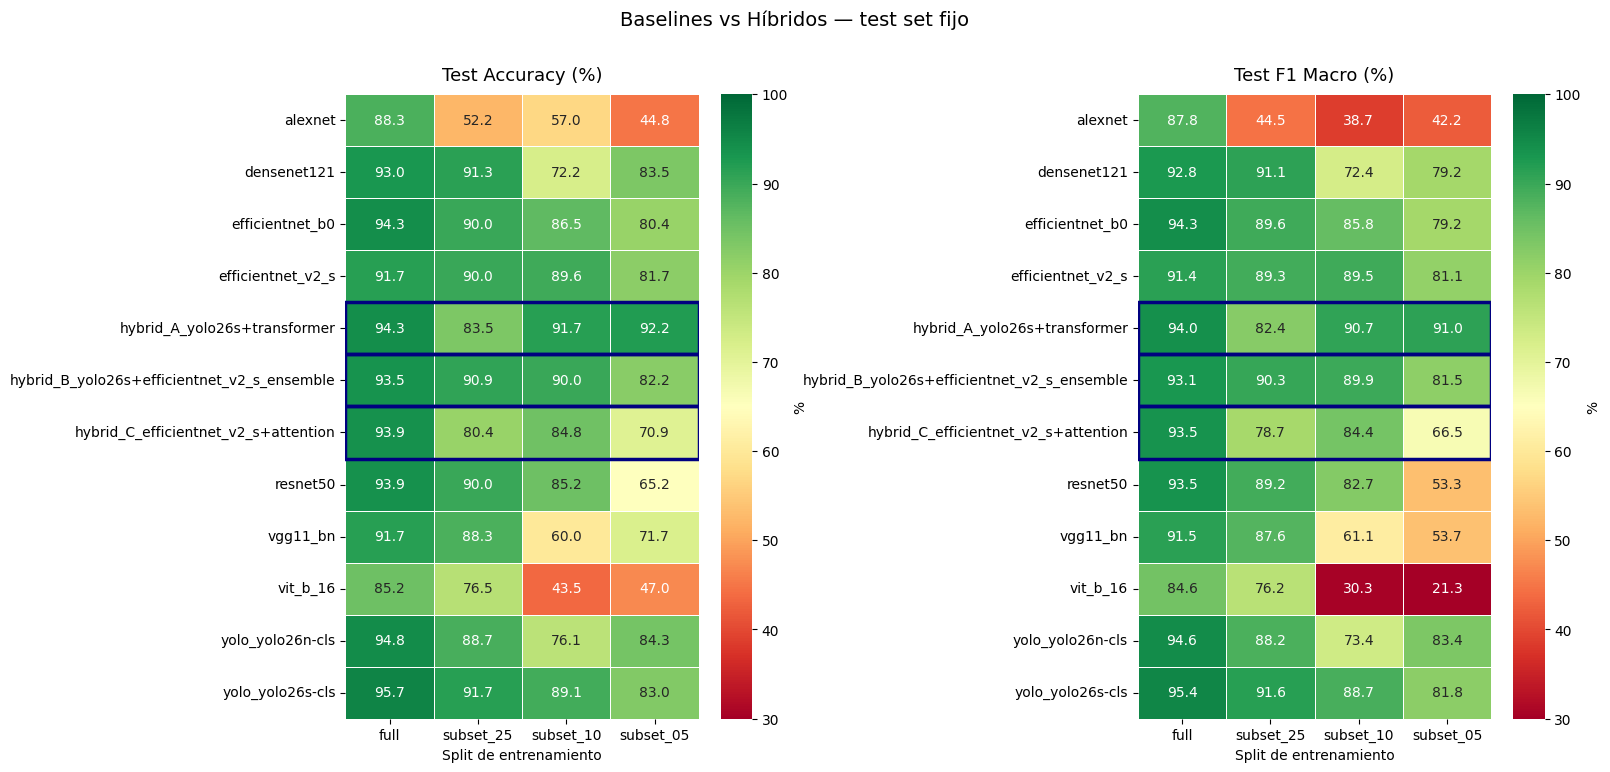

In [15]:
# Heatmap comparativo
fig, axes = plt.subplots(1, 2, figsize=(16, max(5, len(pivot_acc) * 0.55 + 1)))

for ax, pivot, title in zip(axes, [pivot_acc, pivot_f1], ["Test Accuracy (%)", "Test F1 Macro (%)"]):
    pivot_plot = pivot.reindex(columns=split_order)
    sns.heatmap(
        pivot_plot, ax=ax, annot=True, fmt=".1f",
        cmap="RdYlGn", vmin=30, vmax=100,
        linewidths=0.5, cbar_kws={"label": "%"},
    )
    ax.set_title(title, fontsize=13, pad=10)
    ax.set_xlabel("Split de entrenamiento")
    ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=0)
    ax.tick_params(axis="y", rotation=0)

    # Resaltar filas de híbridos
    for i, model in enumerate(pivot_plot.index):
        if model.startswith("hybrid_"):
            ax.add_patch(plt.Rectangle(
                (0, i), len(split_order), 1,
                fill=False, edgecolor="navy", linewidth=2.5, zorder=3
            ))

plt.suptitle("Baselines vs Híbridos — test set fijo", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "hybrid_comparison.png", bbox_inches="tight", dpi=150)
plt.show()




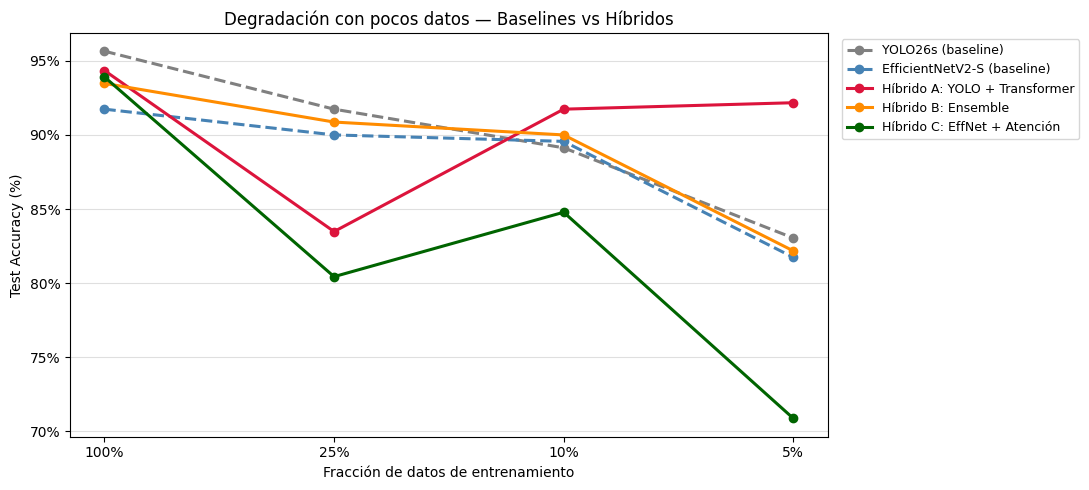

In [16]:
# Curva de degradación: baselines top vs híbridos
fig, ax = plt.subplots(figsize=(11, 5))

x_pos    = np.arange(len(split_order))
x_labels = {"full": "100%", "subset_25": "25%", "subset_10": "10%", "subset_05": "5%"} 

highlight = {
    "yolo_yolo26s-cls":                    ("YOLO26s (baseline)", "--", "gray"),
    "efficientnet_v2_s":                   ("EfficientNetV2-S (baseline)", "--", "steelblue"),
    "hybrid_A_yolo26s+transformer":        ("Híbrido A: YOLO + Transformer", "-", "crimson"),
    "hybrid_B_yolo26s+efficientnet_v2_s_ensemble": ("Híbrido B: Ensemble", "-", "darkorange"),
    "hybrid_C_efficientnet_v2_s+attention": ("Híbrido C: EffNet + Atención", "-", "darkgreen"),
}

for model_name, (label, ls, color) in highlight.items():
    sub = df[df["model"] == model_name].set_index("split")
    y = [sub.loc[s, "test_acc"] * 100 if s in sub.index else np.nan for s in split_order]
    ax.plot(x_pos, y, marker="o", linestyle=ls, color=color, label=label, linewidth=2.2)

ax.set_xticks(x_pos)
ax.set_xticklabels([x_labels[s] for s in split_order])
ax.set_xlabel("Fracción de datos de entrenamiento")
ax.set_ylabel("Test Accuracy (%)")
ax.set_title("Degradación con pocos datos — Baselines vs Híbridos")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
ax.grid(axis="y", alpha=0.4)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "hybrid_degradation.png", bbox_inches="tight", dpi=150)
plt.show()

